# Python Lesson 33: Differentiability

**Concept page:** `wiki/concepts/differentiability.md` · **Area:** calculus

**You will be able to:**
- see why |x|, jumps and vertical tangents fail
- compare left and right slopes numerically
- know how ReLU is handled in practice

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Corner: |x| at 0

In [2]:
f=np.abs
for h in (1e-1,1e-3,1e-6): print(h,"right:",(f(h)-f(0))/h,"left:",(f(0)-f(-h))/h)

0.1 right: 1.0 left: -1.0
0.001 right: 1.0 left: -1.0
1e-06 right: 1.0 left: -1.0


## 2. Jump discontinuity

In [3]:
g=lambda x: x+1 if x>=-1 else 2
for h in (1e-1,1e-3,1e-6): print(h,"right:",(g(-1+h)-g(-1))/h,"left:",(g(-1)-g(-1-h))/h)

0.1 right: 0.9999999999999998 left: -20.0
0.001 right: 1.0000000000000009 left: -2000.0
1e-06 right: 1.0000000000287557 left: -2000000.0


## 3. Vertical tangent: x^(1/3)

In [4]:
cbrt=np.cbrt
for h in (1e-1,1e-3,1e-6,1e-9): print(h,(cbrt(h)-cbrt(0))/h)    # grows without bound

0.1 4.641588833612779
0.001 100.0
1e-06 10000.0
1e-09 1000000.0


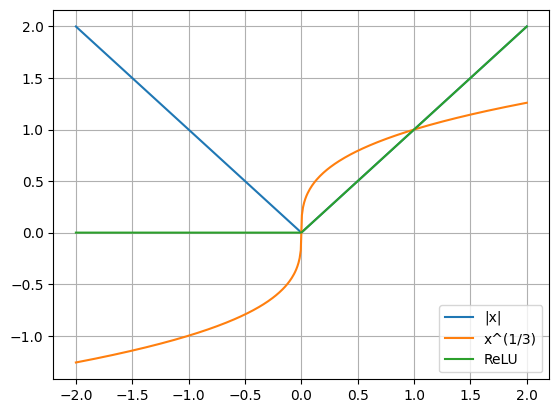

In [5]:
x=np.linspace(-2,2,400); plt.plot(x,np.abs(x),label='|x|'); plt.plot(x,np.cbrt(x),label='x^(1/3)'); plt.plot(x,np.maximum(0,x),label='ReLU'); plt.legend(); plt.grid(True); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 basic ch. 1 (limits and continuity) lays the groundwork: a function must be continuous before it can be differentiable. |x| is continuous at 0 (|h|→0) yet not differentiable there.

In [6]:
print([abs(h) for h in (1e-1,1e-3,1e-6)])

[0.1, 0.001, 1e-06]


## Exercises

**Exercise 1.** Write `one_sided(f,x0)` returning (left slope, right slope) at tiny h and use it on ReLU at 0.

In [7]:
# your code here

**Exercise 2.** Is f(x)=x|x| differentiable at 0? Check numerically.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
def one_sided(f,x0,h=1e-8): return (f(x0)-f(x0-h))/h,(f(x0+h)-f(x0))/h
l,r=one_sided(lambda t:max(0,t),0); print(l,r); assert (l,r)==(0.0,1.0)

0.0 1.0


In [10]:
# Solution 2
l,r=one_sided(lambda t:t*abs(t),0); print(l,r); assert abs(l)<1e-6 and abs(r)<1e-6

1e-08 1e-08
